In [3]:
import os
import shutil
import pandas as pd
import numpy as np

In [111]:
# Select folder Intersections
src = r'C:/Users/zuzka/Desktop/temporary_work/2023-02-14-16_Intersections/'
df = pd.read_csv(src+'2023-02-14-16_Intersections54wt_plexA_mask.tif.csv', sep = "\t")  
df[['A', 'ID']] = df[',"id'].str.split(',"', 1, expand=True)
df['dataset"'] = df['dataset"'].str.replace(r'"', '')
del df[',"id']
del df['A']
df

C:\Users\zuzka\AppData\Local\Temp\ipykernel_26900\452171363.py:4: FutureWarning: In a future version of pandas all arguments of StringMethods.split except for the argument 'pat' will be keyword-only.
  df[['A', 'ID']] = df[',"id'].str.split(',"', 1, expand=True)


,x,data_y,data_y_rounded,high_random_y_rounded,y_diff,"dataset""",ID
0,0.000,0.000000,0.000,0.000,0.000,54wt_plexA_mask.tif,1
1,0.005,0.000000,0.000,0.007,0.007,54wt_plexA_mask.tif,2
2,0.010,0.000000,0.000,0.012,0.012,54wt_plexA_mask.tif,3
3,0.015,0.000000,0.000,0.017,0.017,54wt_plexA_mask.tif,4
4,0.020,0.000000,0.000,0.022,0.022,54wt_plexA_mask.tif,5
5,0.025,0.000000,0.000,0.027,0.027,54wt_plexA_mask.tif,6
6,0.030,0.000000,0.000,0.032,0.032,54wt_plexA_mask.tif,7
7,0.035,0.000000,0.000,0.038,0.038,54wt_plexA_mask.tif,8
8,0.040,0.006862,0.007,0.043,0.036,54wt_plexA_mask.tif,9
9,0.045,0.019169,0.019,0.048,0.029,54wt_plexA_mask.tif,10


In [77]:
count = 0
xs = []
diffs = []
for row,val in enumerate(df["x"]):
    if row<(len(df)-1):
        if (df["y_diff"][row] <= 0.015) and (df["data_y"][row] != 0):
            diff = df["x"][row+1] - df["x"][row]
            if diff > 0.05:
                count += 1
                print("wanted x: ", df["x"][row+1])
            else:
                xs.append(df["x"][row+1])
                diffs.append(diff)
max_local_diff = max(diffs)
print(max_local_diff)
print(xs[(diffs.index(max_local_diff))])
last_index = max(loc for loc, val in enumerate(diffs) if val == max_local_diff)
print(xs[last_index])
        #print("wanted x: ", df["x"][row+1])
        #print("d: ", diff)
print(count)
print((xs, diff))

0.0050000000000000044
0.05
0.05
0
([0.05, 0.055], 0.0049999999999999975)


In [113]:
df_filtered = df[df["y_diff"]<0.015]
df_filtered = df_filtered.reset_index()
df_filtered

,index,x,data_y,data_y_rounded,high_random_y_rounded,y_diff,"dataset""",ID
0,0,0.000,0.000000,0.000,0.000,0.000,54wt_plexA_mask.tif,1
1,1,0.005,0.000000,0.000,0.007,0.007,54wt_plexA_mask.tif,2
2,2,0.010,0.000000,0.000,0.012,0.012,54wt_plexA_mask.tif,3
3,13,0.065,0.052546,0.053,0.067,0.014,54wt_plexA_mask.tif,14
4,15,0.075,0.066202,0.066,0.078,0.012,54wt_plexA_mask.tif,16
5,17,0.095,0.110278,0.110,0.097,0.013,54wt_plexA_mask.tif,20


In [116]:
intersections = []
for row,val in enumerate(df_filtered["x"]):
    if row<(len(df_filtered)-1):
        diff = df_filtered["x"][row+1] - df_filtered["x"][row]
        if diff > 0.025:
            intersections.append((df_filtered["x"][row+1]))
            print("wanted x: ",df_filtered["x"][row+1])
        print("d: ", diff)
        
idf = pd.DataFrame()

if len(intersections)>2:
    print("Yes")
else:
    print("No")

d:  0.005
d:  0.005
wanted x:  0.065
d:  0.055
d:  0.009999999999999995
d:  0.020000000000000004
No


In [117]:
src = r'C:/Users/zuzka/Desktop/temporary_work/2023-02-14-16_Intersections/'

def dfCleaner(dataframe):
                dataframe[['A', 'ID']] = dataframe[',"id'].str.split(',"', 1, expand=True)
                dataframe['dataset"'] = dataframe['dataset"'].str.replace(r'"', '')
                del dataframe[',"id']
                del dataframe['A']
                return(dataframe)
            
def intersectionExtractor(dataframe):
    df_filtered = dataframe[dataframe["y_diff"]<0.015]
    df_filtered = df_filtered.reset_index()
    for row,val in enumerate(df_filtered["x"]): 
        if row<(len(df_filtered)-1):
            diff = df_filtered["x"][row+1] - df_filtered["x"][row]
            if diff > 0.025:
                intersections.append((df_filtered["x"][row+1]))
    if (len(intersections)<2):
        intersections.append(np.nan)
    if (len(intersections)<2):
        intersections.append(np.nan)
        print("missing: ",intersections)
    return(intersections)
          
a = -1    
idf =  pd.DataFrame(columns=["dataset", "i1", "i2"]) 
more_intersections_list, more_names_list = [], []
for path, subdirs, files in os.walk(src): 
    for name in sorted(files):
        intersections = [] 
        #print(name)
        if name.endswith(".csv"):
            filename = os.path.join(path, name)
            df = pd.read_csv(filename, sep = "\t") 
            dfCleaner(df)
            intersectionExtractor(df)
            #print(intersections)
            temp_dict = {
              "dataset": name,
              "i1": intersections[0],
              "i2": intersections[1]
                }
            idf.loc[len(idf)]=temp_dict
            if (len(intersections)>2):
                more_names_list.append(name)
                more_intersections_list.append(intersections)
                print(name,"- more values: ",intersections)
                
idf["orig_dataset"] = idf["dataset"]
idf

C:\Users\zuzka\AppData\Local\Temp\ipykernel_26900\4035320540.py:4: FutureWarning: In a future version of pandas all arguments of StringMethods.split except for the argument 'pat' will be keyword-only.
  dataframe[['A', 'ID']] = dataframe[',"id'].str.split(',"', 1, expand=True)
C:\Users\zuzka\AppData\Local\Temp\ipykernel_26900\4035320540.py:4: FutureWarning: In a future version of pandas all arguments of StringMethods.split except for the argument 'pat' will be keyword-only.
  dataframe[['A', 'ID']] = dataframe[',"id'].str.split(',"', 1, expand=True)
C:\Users\zuzka\AppData\Local\Temp\ipykernel_26900\4035320540.py:4: FutureWarning: In a future version of pandas all arguments of StringMethods.split except for the argument 'pat' will be keyword-only.
  dataframe[['A', 'ID']] = dataframe[',"id'].str.split(',"', 1, expand=True)
C:\Users\zuzka\AppData\Local\Temp\ipykernel_26900\4035320540.py:4: FutureWarning: In a future version of pandas all arguments of StringMethods.split except for the ar

2023-02-14-16_Intersections79mut_plexA_mask.tif.csv - more values:  [0.09, 0.395, 0.455]
missing:  [nan, nan]


C:\Users\zuzka\AppData\Local\Temp\ipykernel_26900\4035320540.py:4: FutureWarning: In a future version of pandas all arguments of StringMethods.split except for the argument 'pat' will be keyword-only.
  dataframe[['A', 'ID']] = dataframe[',"id'].str.split(',"', 1, expand=True)
C:\Users\zuzka\AppData\Local\Temp\ipykernel_26900\4035320540.py:4: FutureWarning: In a future version of pandas all arguments of StringMethods.split except for the argument 'pat' will be keyword-only.
  dataframe[['A', 'ID']] = dataframe[',"id'].str.split(',"', 1, expand=True)
C:\Users\zuzka\AppData\Local\Temp\ipykernel_26900\4035320540.py:4: FutureWarning: In a future version of pandas all arguments of StringMethods.split except for the argument 'pat' will be keyword-only.
  dataframe[['A', 'ID']] = dataframe[',"id'].str.split(',"', 1, expand=True)


,dataset,i1,i2,orig_dataset
0,2023-02-14-16_Intersections01wt_sem1a_mask.tif...,0.045,NaN,2023-02-14-16_Intersections01wt_sem1a_mask.tif...
1,2023-02-14-16_Intersections02wt_sem1a_mask.tif...,0.065,NaN,2023-02-14-16_Intersections02wt_sem1a_mask.tif...
2,2023-02-14-16_Intersections03wt_sem1a_mask.tif...,0.075,NaN,2023-02-14-16_Intersections03wt_sem1a_mask.tif...
3,2023-02-14-16_Intersections04wt_sem1a_mask.tif...,0.045,NaN,2023-02-14-16_Intersections04wt_sem1a_mask.tif...
4,2023-02-14-16_Intersections05wt_sem1a_mask.tif...,0.045,NaN,2023-02-14-16_Intersections05wt_sem1a_mask.tif...
...,...,...,...,...
95,2023-02-14-16_Intersections95mut_plexA_mask.ti...,0.065,NaN,2023-02-14-16_Intersections95mut_plexA_mask.ti...
96,2023-02-14-16_Intersections96mut_plexA_mask.ti...,0.065,NaN,2023-02-14-16_Intersections96mut_plexA_mask.ti...
97,2023-02-14-16_Intersections97mut_plexA_mask.ti...,0.085,NaN,2023-02-14-16_Intersections97mut_plexA_mask.ti...
98,2023-02-14-16_Intersections98mut_plexA_mask.ti...,0.085,NaN,2023-02-14-16_Intersections98mut_plexA_mask.ti...


In [15]:
idf["dataset"] = idf["dataset"].str.replace("2part_", "")
idf["dataset"] = idf["dataset"].str.replace("1part_", "")
idf["dataset"] = idf["dataset"].str.replace("3part_", "")
idf["dataset"] = idf["dataset"].str.replace("4part_", "")
idf["group"] = idf["dataset"].str.split("_", 2, expand=True)[1].str.strip("CHO")
idf

,dataset,i1,i2,orig_dataset,group
0,01_CHOmut_sem1b.csv,0.130,1.830,01_CHOmut_sem1b.csv,mut
1,01_CHOwt_sem1b.csv,0.185,NaN,01_CHOwt_sem1b.csv,wt
2,02_CHOmut_sem1b.csv,0.155,1.340,02_CHOmut_sem1b.csv,mut
3,02_CHOwt_sem1b.csv,0.165,NaN,02_CHOwt_sem1b.csv,wt
4,03_CHOmut_sem1b.csv,0.165,1.855,03_CHOmut_sem1b.csv,mut
...,...,...,...,...,...
89,39_CHOmut_sem1b.csv,0.265,NaN,39_2part_CHOmut_sem1b.csv,mut
90,39_CHOmut_sem1b.csv,0.315,0.740,39_3part_CHOmut_sem1b.csv,mut
91,39_CHOwt_sem1b.csv,0.145,NaN,39_CHOwt_sem1b.csv,wt
92,40_CHOmut_sem1b.csv,0.145,NaN,40_CHOmut_sem1b.csv,mut


In [118]:
idf[idf['i1']>0.8]

,dataset,i1,i2,orig_dataset
6,2023-02-14-16_Intersections07wt_sem1a_mask.tif...,1.98,NaN,2023-02-14-16_Intersections07wt_sem1a_mask.tif...
20,2023-02-14-16_Intersections20wt_sem1a_mask.tif...,11.03,NaN,2023-02-14-16_Intersections20wt_sem1a_mask.tif...


In [103]:
list_of_tuples = list(zip(more_names_list, more_intersections_list))
dfm = pd.DataFrame(list_of_tuples, columns = ['Name', 'Intersections'])
dfm
dfm.to_csv("intersections_table_problematic_data.csv")

In [119]:
tidf = idf[~idf['dataset'].isin(more_names_list)]
tidf

,dataset,i1,i2,orig_dataset
0,2023-02-14-16_Intersections01wt_sem1a_mask.tif...,0.045,NaN,2023-02-14-16_Intersections01wt_sem1a_mask.tif...
1,2023-02-14-16_Intersections02wt_sem1a_mask.tif...,0.065,NaN,2023-02-14-16_Intersections02wt_sem1a_mask.tif...
2,2023-02-14-16_Intersections03wt_sem1a_mask.tif...,0.075,NaN,2023-02-14-16_Intersections03wt_sem1a_mask.tif...
3,2023-02-14-16_Intersections04wt_sem1a_mask.tif...,0.045,NaN,2023-02-14-16_Intersections04wt_sem1a_mask.tif...
4,2023-02-14-16_Intersections05wt_sem1a_mask.tif...,0.045,NaN,2023-02-14-16_Intersections05wt_sem1a_mask.tif...
...,...,...,...,...
95,2023-02-14-16_Intersections95mut_plexA_mask.ti...,0.065,NaN,2023-02-14-16_Intersections95mut_plexA_mask.ti...
96,2023-02-14-16_Intersections96mut_plexA_mask.ti...,0.065,NaN,2023-02-14-16_Intersections96mut_plexA_mask.ti...
97,2023-02-14-16_Intersections97mut_plexA_mask.ti...,0.085,NaN,2023-02-14-16_Intersections97mut_plexA_mask.ti...
98,2023-02-14-16_Intersections98mut_plexA_mask.ti...,0.085,NaN,2023-02-14-16_Intersections98mut_plexA_mask.ti...


In [120]:
tidf.to_csv("C:/Users/zuzka/Desktop/temporary_work/intersections_table.csv")

In [107]:
tidf[tidf["i2"]<(2*tidf["i1"])]

,dataset,i1,i2,orig_dataset
83,2023-02-14-16_Intersections83mut_plexA_mask.ti...,0.085,0.14,2023-02-14-16_Intersections83mut_plexA_mask.ti...


<AxesSubplot:xlabel='group', ylabel='i1'>

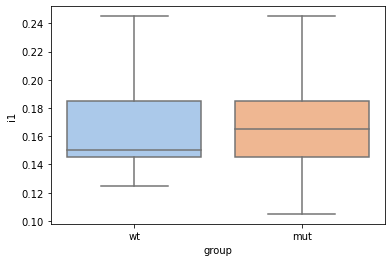

In [134]:
sns.boxplot(x="group", y="i1", data=tidf, palette="pastel", order = ["wt", "mut"], showfliers = False)


<AxesSubplot:xlabel='group', ylabel='i1'>

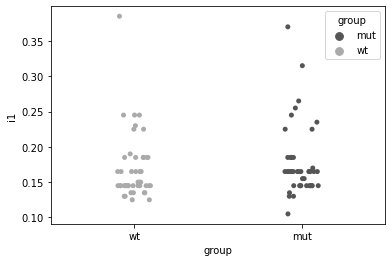

In [27]:
sns.stripplot(x="group", y="i1", data=tidf, hue = "group", palette="gray", order = ["wt", "mut"])

In [152]:
tidf["i1"][tidf["group"]=="wt"].mean()

0.1692391304347825

In [153]:
tidf["i1"][tidf["group"]=="mut"].mean()

0.17727272727272722

In [154]:
tidf["i2"][tidf["group"]=="wt"].mean()

1.8205882352941176

In [155]:
tidf["i2"][tidf["group"]=="mut"].mean()

1.6337499999999998

In [24]:
from scipy import stats

In [25]:
stats.ttest_ind(tidf["i1"][tidf["group"]=="mut"], tidf["i1"][tidf["group"]=="wt"])

Ttest_indResult(statistic=0.7904465557582376, pvalue=0.4313920396350721)